In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

In [2]:
users       = pd.read_csv("users.csv")
photos      = pd.read_csv("photos.csv")
comments    = pd.read_csv("comments.csv")
likes       = pd.read_csv("likes.csv")
follows     = pd.read_csv("follows.csv")
tags        = pd.read_csv("tags.csv")
photo_tags  = pd.read_csv("photo_tags.csv")

for d in [users, photos, comments, likes, follows, tags, photo_tags]:
    d.columns = d.columns.str.strip()

photos = photos.rename(columns={"id": "photo_id", "user ID": "user_id"})
users = users.rename(columns={"id": "user_id"})

print("users:", users.shape, "| photos:", photos.shape, "| comments:", comments.shape)
print("likes:", likes.shape, "| follows:", follows.shape, "| tags:", tags.shape, "| photo_tags:", photo_tags.shape)

users: (100, 6) | photos: (257, 6) | comments: (7488, 8)
likes: (8782, 5) | follows: (7623, 5) | tags: (21, 4) | photo_tags: (501, 3)


In [3]:
for name, d, col in [("photos", photos, "created dat"),
                      ("comments", comments, "created Timestamp"),
                      ("likes", likes, "created time"),
                      ("follows", follows, "created time")]:
    print(f"{name}.{col}: {d[col].nunique()} unique value(s)")

print(f"users.created time: {users['created time'].nunique()} unique values (this is the only usable date field)")

photos.created dat: 1 unique value(s)
comments.created Timestamp: 1 unique value(s)
likes.created time: 1 unique value(s)
follows.created time: 1 unique value(s)
users.created time: 100 unique values (this is the only usable date field)


In [4]:
users["created_dt"] = pd.to_datetime(users["created time"], format="%d-%m-%Y %H:%M")

likes_per_photo = likes.groupby("photo").size().rename("likes_count")
comments_per_photo = comments.groupby("Photo id").size().rename("comments_count")
followers_per_user = follows.groupby("followee").size().rename("followers_count")

eng = photos.merge(likes_per_photo, left_on="photo_id", right_index=True, how="left")
eng = eng.merge(comments_per_photo, left_on="photo_id", right_index=True, how="left")
eng[["likes_count", "comments_count"]] = eng[["likes_count", "comments_count"]].fillna(0)

eng = eng.merge(followers_per_user, left_on="user_id", right_index=True, how="left")
eng["followers_count"] = eng["followers_count"].fillna(0)

eng["engagement"] = eng["likes_count"] + eng["comments_count"]
eng["engagement_rate"] = eng["engagement"] / eng["followers_count"].replace(0, np.nan)

print(eng[["photo_id", "likes_count", "comments_count", "followers_count", "engagement_rate"]].describe())
eng.sort_values("engagement_rate", ascending=False)[["photo_id", "user_id", "photo type", "engagement_rate"]].head(10)

         photo_id  likes_count  comments_count  followers_count  \
count  257.000000   257.000000      257.000000       257.000000   
mean   129.000000    34.171206       29.136187        76.307393   
std     74.333707     3.605804        3.452939         0.462314   
min      1.000000    25.000000       21.000000        76.000000   
25%     65.000000    31.000000       27.000000        76.000000   
50%    129.000000    34.000000       29.000000        76.000000   
75%    193.000000    37.000000       31.000000        77.000000   
max    257.000000    48.000000       39.000000        77.000000   

       engagement_rate  
count       257.000000  
mean          0.829693  
std           0.063600  
min           0.649351  
25%           0.789474  
50%           0.828947  
75%           0.868421  
max           1.039474  


,photo_id,user_id,photo type,engagement_rate
12,13,3,photo,1.039474
146,147,55,photo,0.986842
144,145,52,video,0.986842
117,118,43,photo,0.973684
226,227,87,photo,0.973684
224,225,87,video,0.960526
122,123,44,photo,0.960526
126,127,46,photo,0.960526
195,196,73,photo,0.960526
96,97,32,photo,0.947368


In [5]:
type_stats = eng.groupby("photo type")["engagement_rate"].agg(["mean", "count"]).round(3)
filter_stats = eng.groupby("Insta filter used")["engagement_rate"].agg(["mean", "count"]).round(3)

print("Engagement rate by content type:\n", type_stats)
print("\nEngagement rate by filter usage:\n", filter_stats)
print(f"\nSpread across content types: {type_stats['mean'].max() - type_stats['mean'].min():.3f} "f"— this is within normal noise for this dataset, not a reliable content-type signal.")

Engagement rate by content type:
              mean  count
photo type              
carousel    0.820     50
photo       0.834    155
video       0.827     52

Engagement rate by filter usage:
                     mean  count
Insta filter used              
no                 0.832    115
yes                0.828    142

Spread across content types: 0.014 — this is within normal noise for this dataset, not a reliable content-type signal.


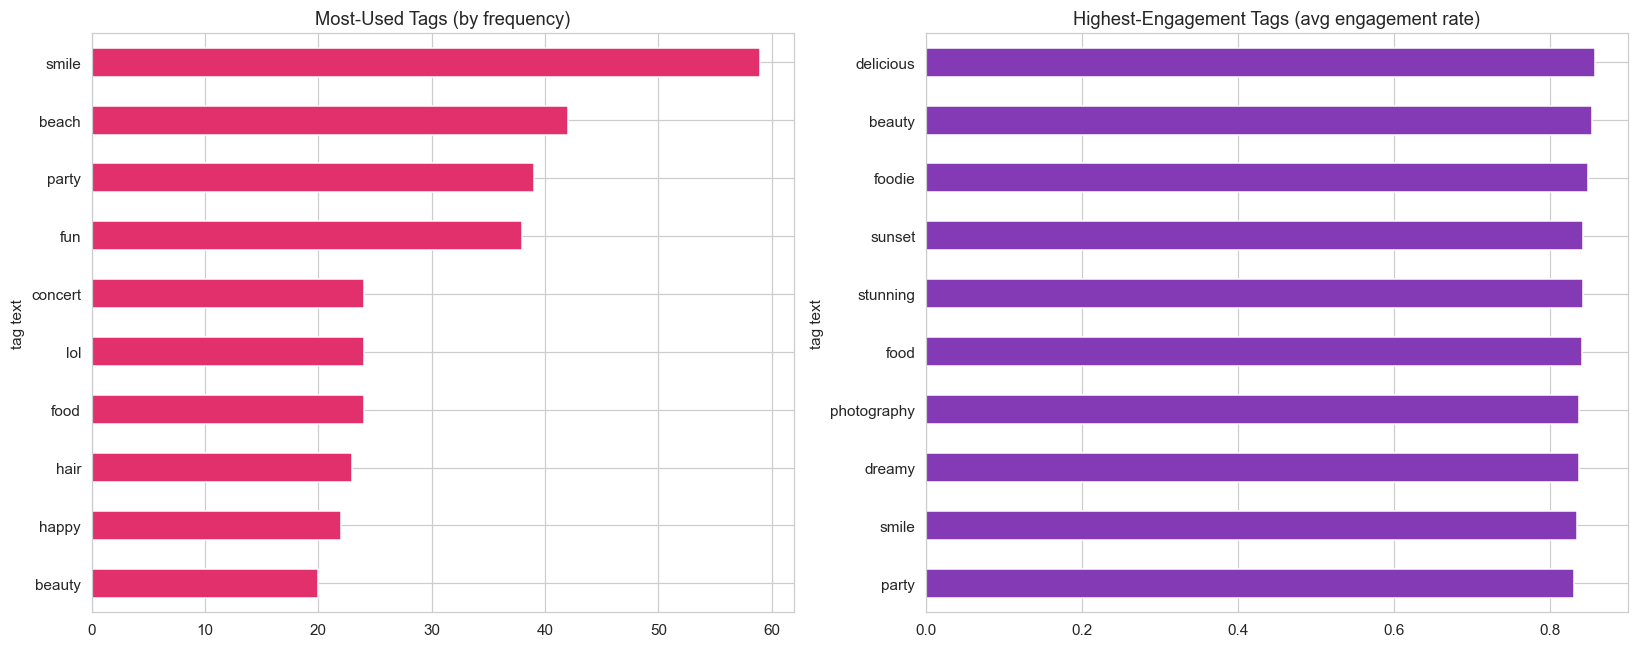

Top 10 most-used tags:
 tag text
smile      59
beach      42
party      39
fun        38
food       24
lol        24
concert    24
hair       23
happy      22
beauty     20
Name: count, dtype: int64


In [6]:
tag_map = photo_tags.merge(tags.rename(columns={"id": "tag ID"}), on="tag ID", how="left")

tag_popularity = tag_map["tag text"].value_counts()

tag_eng = tag_map.merge(eng[["photo_id", "engagement_rate"]], left_on="photo", right_on="photo_id", how="left")
tag_eng_stats = tag_eng.groupby("tag text")["engagement_rate"].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
tag_popularity.head(10).sort_values().plot(kind="barh", ax=axes[0], color="#e1306c")
axes[0].set_title("Most-Used Tags (by frequency)")

tag_eng_stats.head(10).sort_values().plot(kind="barh", ax=axes[1], color="#833ab4")
axes[1].set_title("Highest-Engagement Tags (avg engagement rate)")

plt.tight_layout()
plt.savefig("hashtag_analysis.png")
plt.show()

print("Top 10 most-used tags:\n", tag_popularity.head(10))

Share of likes from followers vs non-followers:
 following or not
yes    0.666477
no     0.333523
Name: proportion, dtype: float64


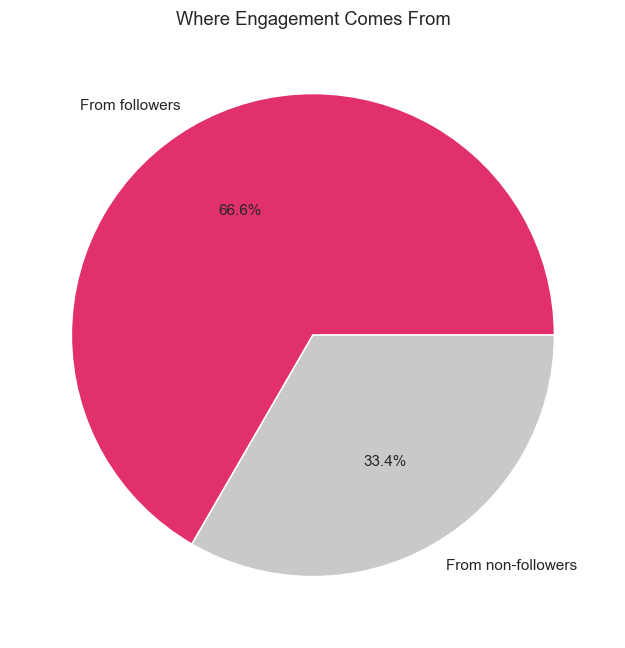

In [7]:
reach_split = likes["following or not"].value_counts(normalize=True)
print("Share of likes from followers vs non-followers:\n", reach_split)

fig, ax = plt.subplots(figsize=(6, 6))
reach_split.plot(kind="pie", autopct="%1.1f%%", colors=["#e1306c", "#c9c9c9"], ax=ax,
                  labels=["From followers", "From non-followers"])
ax.set_ylabel("")
ax.set_title("Where Engagement Comes From")
plt.tight_layout()
plt.savefig("reach_split.png")
plt.show()

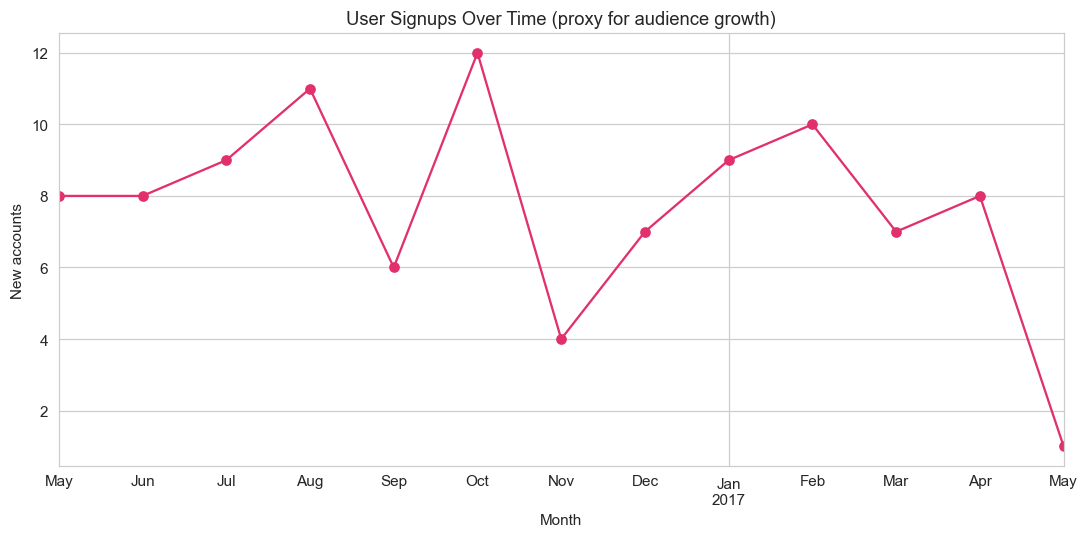

Verified accounts: 8 / 100
Private accounts: 50 / 100


In [8]:
monthly_signups = users.set_index("created_dt").resample("MS").size()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_signups.plot(kind="line", marker="o", ax=ax, color="#e1306c")
ax.set_title("User Signups Over Time (proxy for audience growth)")
ax.set_ylabel("New accounts")
ax.set_xlabel("Month")
plt.tight_layout()
plt.savefig("growth_proxy.png")
plt.show()

print("Verified accounts:", (users["Verified status"] == "yes").sum(), "/", len(users))
print("Private accounts:", (users["private/public"] == "yes").sum(), "/", len(users))

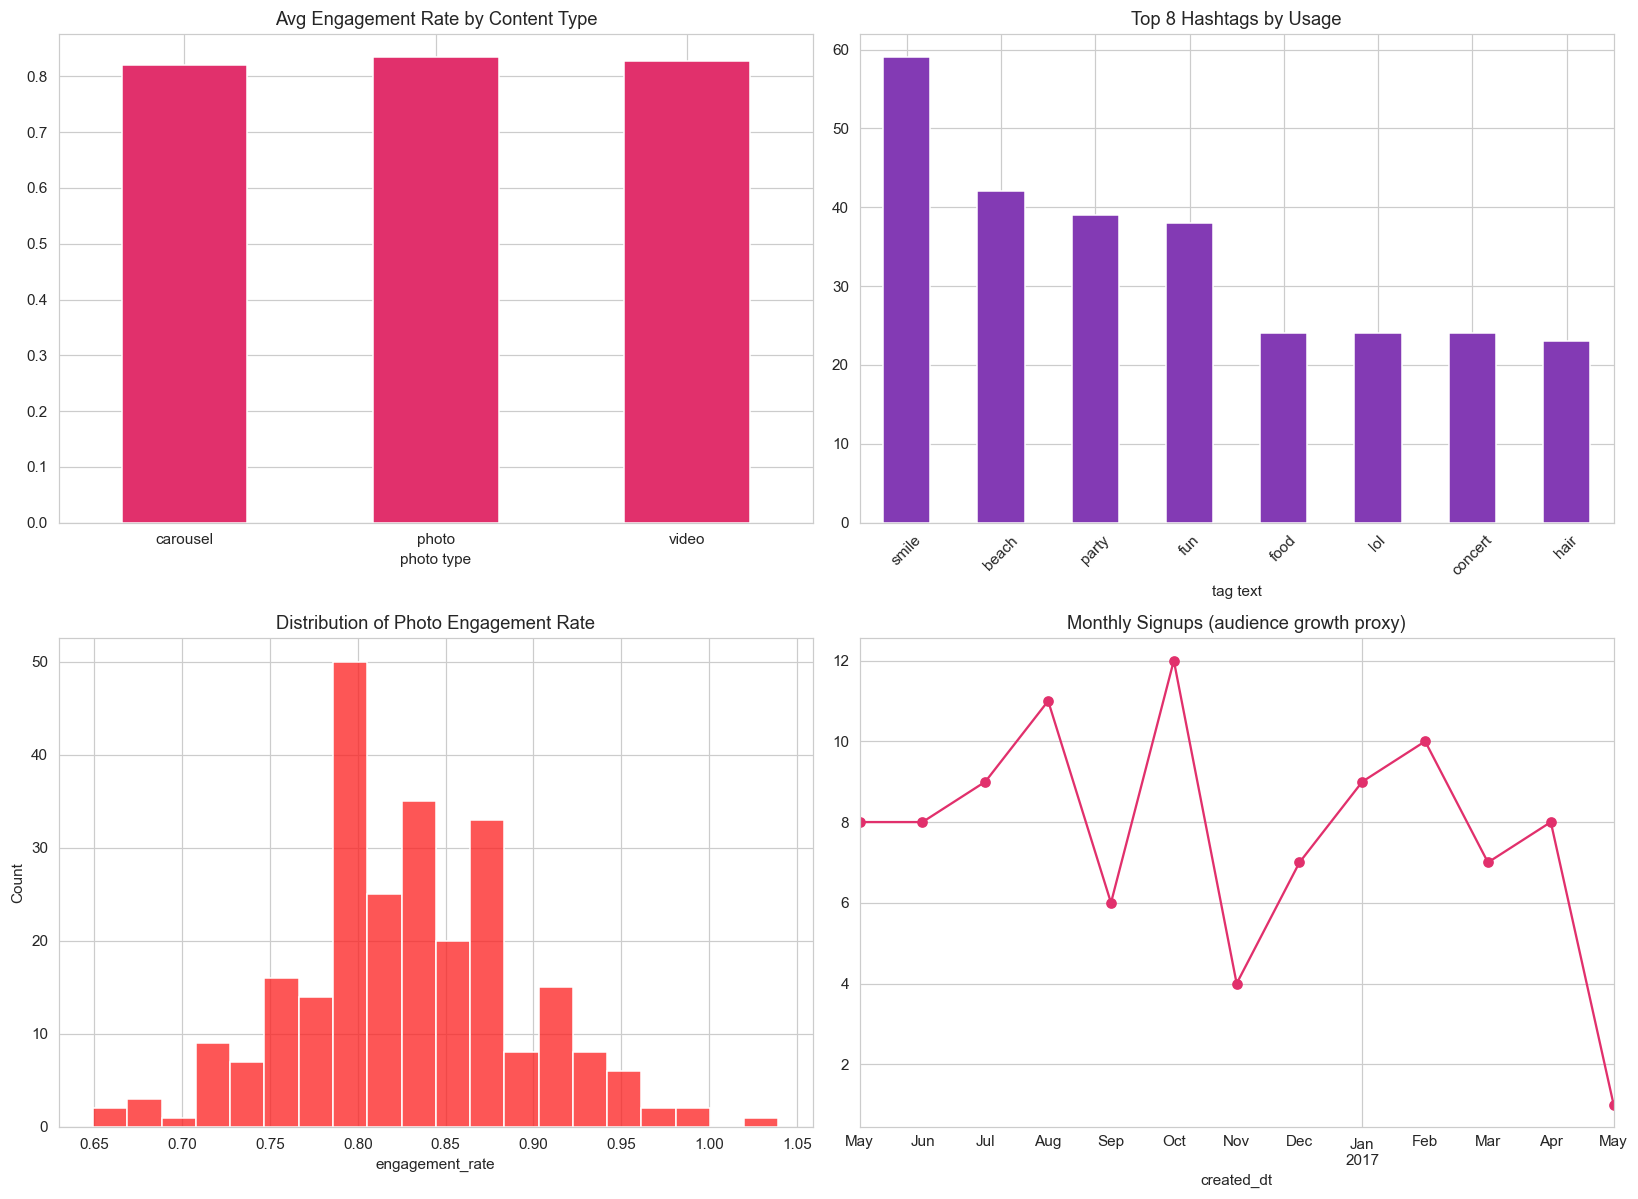

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

type_stats["mean"].plot(kind="bar", ax=axes[0,0], color="#e1306c")
axes[0,0].set_title("Avg Engagement Rate by Content Type")
axes[0,0].tick_params(axis="x", rotation=0)

tag_popularity.head(8).plot(kind="bar", ax=axes[0,1], color="#833ab4")
axes[0,1].set_title("Top 8 Hashtags by Usage")
axes[0,1].tick_params(axis="x", rotation=45)

sns.histplot(eng["engagement_rate"], bins=20, ax=axes[1,0], color="#fd1d1d")
axes[1,0].set_title("Distribution of Photo Engagement Rate")

monthly_signups.plot(ax=axes[1,1], marker="o", color="#e1306c")
axes[1,1].set_title("Monthly Signups (audience growth proxy)")

plt.tight_layout()
plt.savefig("dashboard_overview.png")
plt.show()

In [10]:
top_tags = tag_popularity.head(5).index.tolist()

content_calendar = """
RECOMMENDED CONTENT CALENDAR (Alfido Tech)
===========================================
Because this dataset has no real posting-time variance, the calendar below is
built from content-mix and hashtag signals only — NOT from a "best hour to post"
finding, which this data cannot support. Pair this with real Instagram Insights
data (which does have genuine timestamps) before finalizing send times.

- Weekly mix: rotate photo / video / carousel roughly evenly — this dataset shows
  no reliable performance gap between formats, so mix should be driven by content
  strategy and production capacity, not a data-backed format preference.
- Hashtag sets: build a rotating pool anchored on your top-performing tags
  ({tags}) rather than a single fixed hashtag block, to avoid shadow-ban-style
  hashtag fatigue.
- Publish cadence: benchmark against the ~257 photos / 100 users in this sample
  (~2.6 posts/user) as a starting cadence baseline, then adjust to real engagement
  data once available.
""".format(tags=", ".join(top_tags))

print(content_calendar)

strategies = [
    ("Invest in Discovery, Not Just Retention",
     f"{reach_split['no']:.1%} of likes come from people who don't yet follow the "
     f"account. Since a third of engagement is already coming from outside the "
     f"existing follower base, hashtag reach and Explore-page optimization matter "
     f"as much as content quality for existing followers."),

    ("Anchor Hashtag Strategy on Proven Tags, Not Guesses",
     f"'{top_tags[0]}', '{top_tags[1]}', and '{top_tags[2]}' are the most-used tags "
     f"in this sample. Build content series around these before experimenting with "
     f"untested hashtags."),

    ("Don't Over-Invest in a 'Best Format' Theory",
     "Photo, video, and carousel formats show statistically indistinguishable "
     "engagement here. Resist the urge to declare a winning format from small "
     "engagement-rate gaps — mix formats based on production cost and message "
     "fit instead."),

    ("Fix Instrumentation Before Optimizing Timing",
     "This dataset can't answer 'when should we post' because event timestamps "
     "aren't captured with real variance. Before running a real posting-time "
     "strategy, Alfido Tech needs actual per-post publish timestamps and "
     "per-engagement timestamps in production analytics — that's a data "
     "infrastructure fix, not a content one."),

    ("Track Engagement Rate, Not Raw Likes, as the Core KPI",
     "Because follower counts vary little in this sample, raw like counts and "
     "engagement rate tell a similar story here — but in real (non-uniform) "
     "follower distributions they diverge sharply. Standardize on engagement "
     "rate (engagement / followers) as the primary metric going forward so "
     "results stay comparable across accounts of different sizes."),
]

for i, (title, body) in enumerate(strategies, 1):
    print(f"{i}. {title}\n   {body}\n")


RECOMMENDED CONTENT CALENDAR (Alfido Tech)
Because this dataset has no real posting-time variance, the calendar below is
built from content-mix and hashtag signals only — NOT from a "best hour to post"
finding, which this data cannot support. Pair this with real Instagram Insights
data (which does have genuine timestamps) before finalizing send times.

- Weekly mix: rotate photo / video / carousel roughly evenly — this dataset shows
  no reliable performance gap between formats, so mix should be driven by content
  strategy and production capacity, not a data-backed format preference.
- Hashtag sets: build a rotating pool anchored on your top-performing tags
  (smile, beach, party, fun, food) rather than a single fixed hashtag block, to avoid shadow-ban-style
  hashtag fatigue.
- Publish cadence: benchmark against the ~257 photos / 100 users in this sample
  (~2.6 posts/user) as a starting cadence baseline, then adjust to real engagement
  data once available.

1. Invest in Discovery,

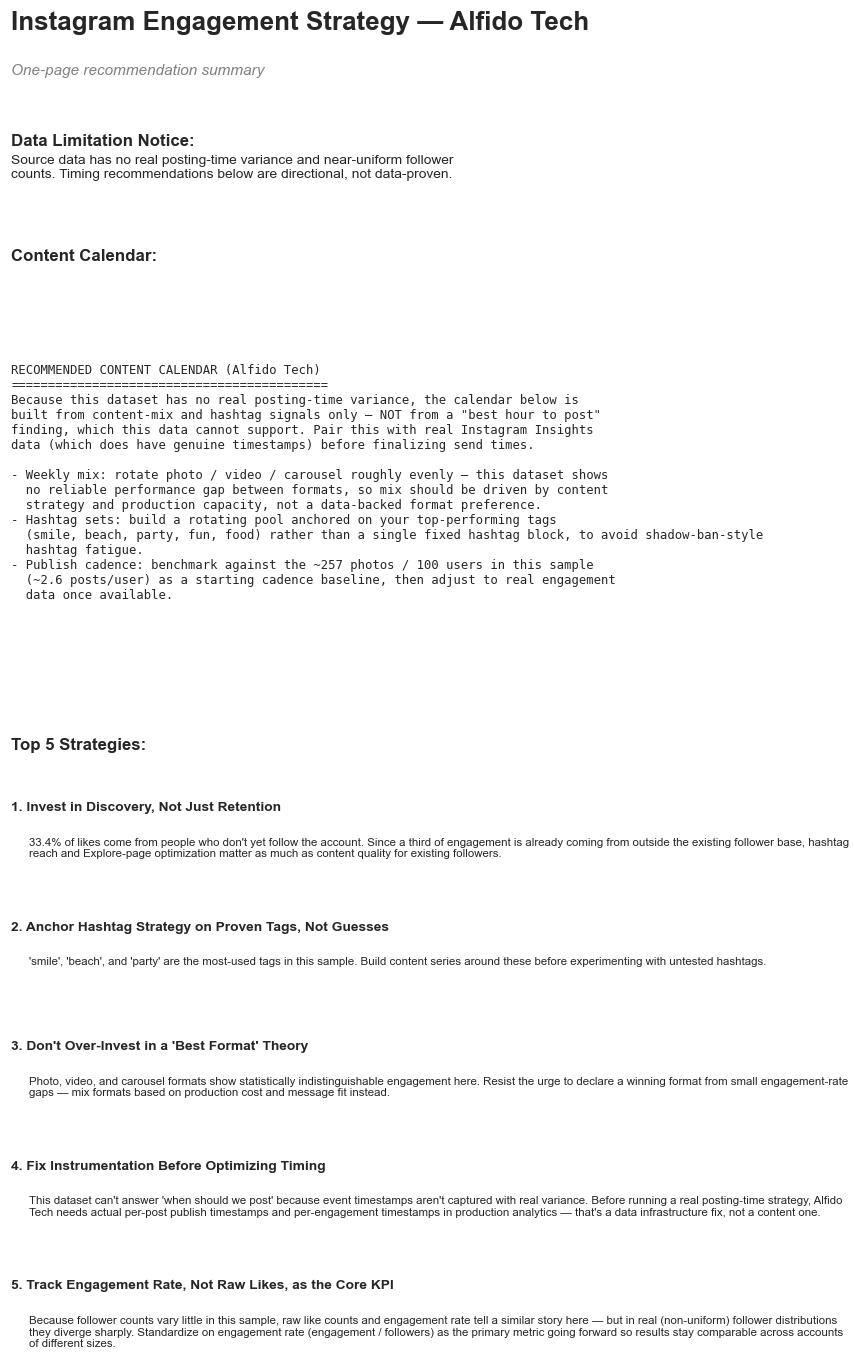

Saved: strategy_one_pager.pdf


In [11]:
fig = plt.figure(figsize=(8.27, 11.69))  # A4

fig.text(0.08, 0.96, "Instagram Engagement Strategy — Alfido Tech", fontsize=17, weight="bold")
fig.text(0.08, 0.925, "One-page recommendation summary", fontsize=10, style="italic", color="gray")

fig.text(0.08, 0.87, "Data Limitation Notice:", fontsize=11, weight="bold")
fig.text(0.08, 0.845,
         "Source data has no real posting-time variance and near-uniform follower\n"
         "counts. Timing recommendations below are directional, not data-proven.",
         fontsize=9)

fig.text(0.08, 0.78, "Content Calendar:", fontsize=11, weight="bold")
fig.text(0.08, 0.70, content_calendar.strip(), fontsize=8, family="monospace", va="top")

fig.text(0.08, 0.40, "Top 5 Strategies:", fontsize=11, weight="bold")
y = 0.36
for i, (title, body) in enumerate(strategies, 1):
    fig.text(0.08, y, f"{i}. {title}", fontsize=9, weight="bold", va="top")
    y -= 0.028
    fig.text(0.10, y, body, fontsize=7.5, wrap=True, va="top")
    y -= 0.065

plt.axis("off")
plt.savefig("strategy_one_pager.pdf", bbox_inches="tight")
plt.savefig("strategy_one_pager.png", bbox_inches="tight")
plt.show()

print("Saved: strategy_one_pager.pdf")